In [1]:
import torch
from torch import nn
from d2l import torch as d2l
batch_size, num_steps = 32, 35
num_hiddens = 256
num_epochs = 100
lr = 1

data = d2l.TimeMachine(batch_size=batch_size, num_steps=num_steps)
vocab_size = len(data.vocab)

In [2]:
class GRUScratch(nn.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        self.sigma = sigma

        def normal(shape):
            return nn.Parameter(torch.randn(shape) * sigma)

        def three():
            return (
                normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                nn.Parameter(torch.zeros(num_hiddens))
            )

        self.W_xz, self.W_hz, self.b_z = three()
        self.W_xr, self.W_hr, self.b_r = three()
        self.W_xh, self.W_hh, self.b_h = three()

    def forward(self, inputs, state=None):
        if state is None:
            H = torch.zeros(
                (inputs.shape[1], self.num_hiddens),
                device=inputs.device
            )
        else:
            H = state

        outputs = []
        for X in inputs:
            Z = torch.sigmoid(X @ self.W_xz + H @ self.W_hz + self.b_z)
            R = torch.sigmoid(X @ self.W_xr + H @ self.W_hr + self.b_r)
            H_tilda = torch.tanh(X @ self.W_xh + (R * H) @ self.W_hh + self.b_h)
            H = Z * H + (1 - Z) * H_tilda
            outputs.append(H)

        return outputs, H

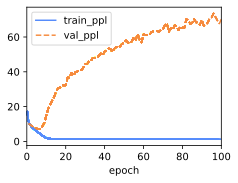

In [3]:
gru = GRUScratch(num_inputs=vocab_size, num_hiddens=num_hiddens)
model = d2l.RNNLMScratch(gru, vocab_size=vocab_size, lr=lr)

trainer = d2l.Trainer(
    max_epochs=num_epochs,
    gradient_clip_val=1,
    num_gpus=1
)
trainer.fit(model, data)

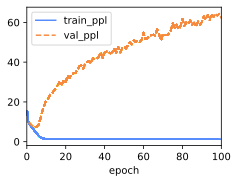

In [4]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 35
num_hiddens = 256
num_epochs = 100
lr = 1

data = d2l.TimeMachine(batch_size=batch_size, num_steps=num_steps)
vocab_size = len(data.vocab)

gru_layer = nn.GRU(vocab_size, num_hiddens)
model = d2l.RNNLM(gru_layer, vocab_size=vocab_size, lr=lr)

trainer = d2l.Trainer(
    max_epochs=num_epochs,
    gradient_clip_val=1,
    num_gpus=1
)
trainer.fit(model, data)